In [114]:
import os
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt
import neurokit2 as nk
import mne
import ecg_plot
import mne
from opensignalsreader import OpenSignalsReader
from scipy.signal import welch
mne.set_log_level('WARNING')

In [23]:
def leer_eeg_bitalino(path):
    fs = 1000          
    columna = 5        
    resolution = 10  

    with open(path, 'r') as f:
        lines = f.readlines()

    fin_header_idx = next(i for i, line in enumerate(lines) if "EndOfHeader" in line)
    df = pd.read_csv(path, sep='\t', skiprows=fin_header_idx + 1, header=None)
    raw_eeg = df.iloc[:, columna].values

    eeg_microvolts = ((((raw_eeg / (2 ** resolution)) - 0.5) * 3.3) / 40000) * 1e6
    t = np.arange(len(eeg_microvolts)) / fs

    return eeg_microvolts, t

In [24]:
def filtrar_eeg(eeg_microvolts):
    data = eeg_microvolts[np.newaxis, :] 
    info = mne.create_info(ch_names=['EEG'], sfreq=1000, ch_types=['eeg'])
    raw = mne.io.RawArray(data, info)

    raw_filtered = raw.copy().filter(l_freq=0.5, h_freq=70, fir_design='firwin') # Filtrar frecuencias sin relevancia clinica (f < 0.5 Hz y f > 70 Hz)
    raw_filtered.notch_filter(freqs=60, fir_design='firwin')                     # Filtrar ruido de linea (60 Hz) con notch

    señal_filtrada = raw_filtered.get_data()[0]
    return señal_filtrada

In [54]:
def obtain_psd(eeg_microvolts):
    data = eeg_microvolts[np.newaxis, :]  # (n_channels, n_times)
    info = mne.create_info(ch_names=['EEG'], sfreq=1000, ch_types=['eeg'])
    raw = mne.io.RawArray(data, info)
    
    psd = raw.compute_psd(method='welch', fmin=0.5, fmax=70, n_fft=2048)
    frequencies = psd.freqs
    power = psd.get_data()[0]
    return power,frequencies

In [72]:
def detectar_parpadeos(signal, umbral, min_tiempo_entre):
    distancia = int(min_tiempo_entre * 1000)
    indices, _ = find_peaks(np.abs(signal), height=umbral, distance=distancia)

    return indices

In [115]:
def potencia_banda(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[mask], freqs[mask])

## Basal 1 - Ojos abiertos, mirando a un punto fijo

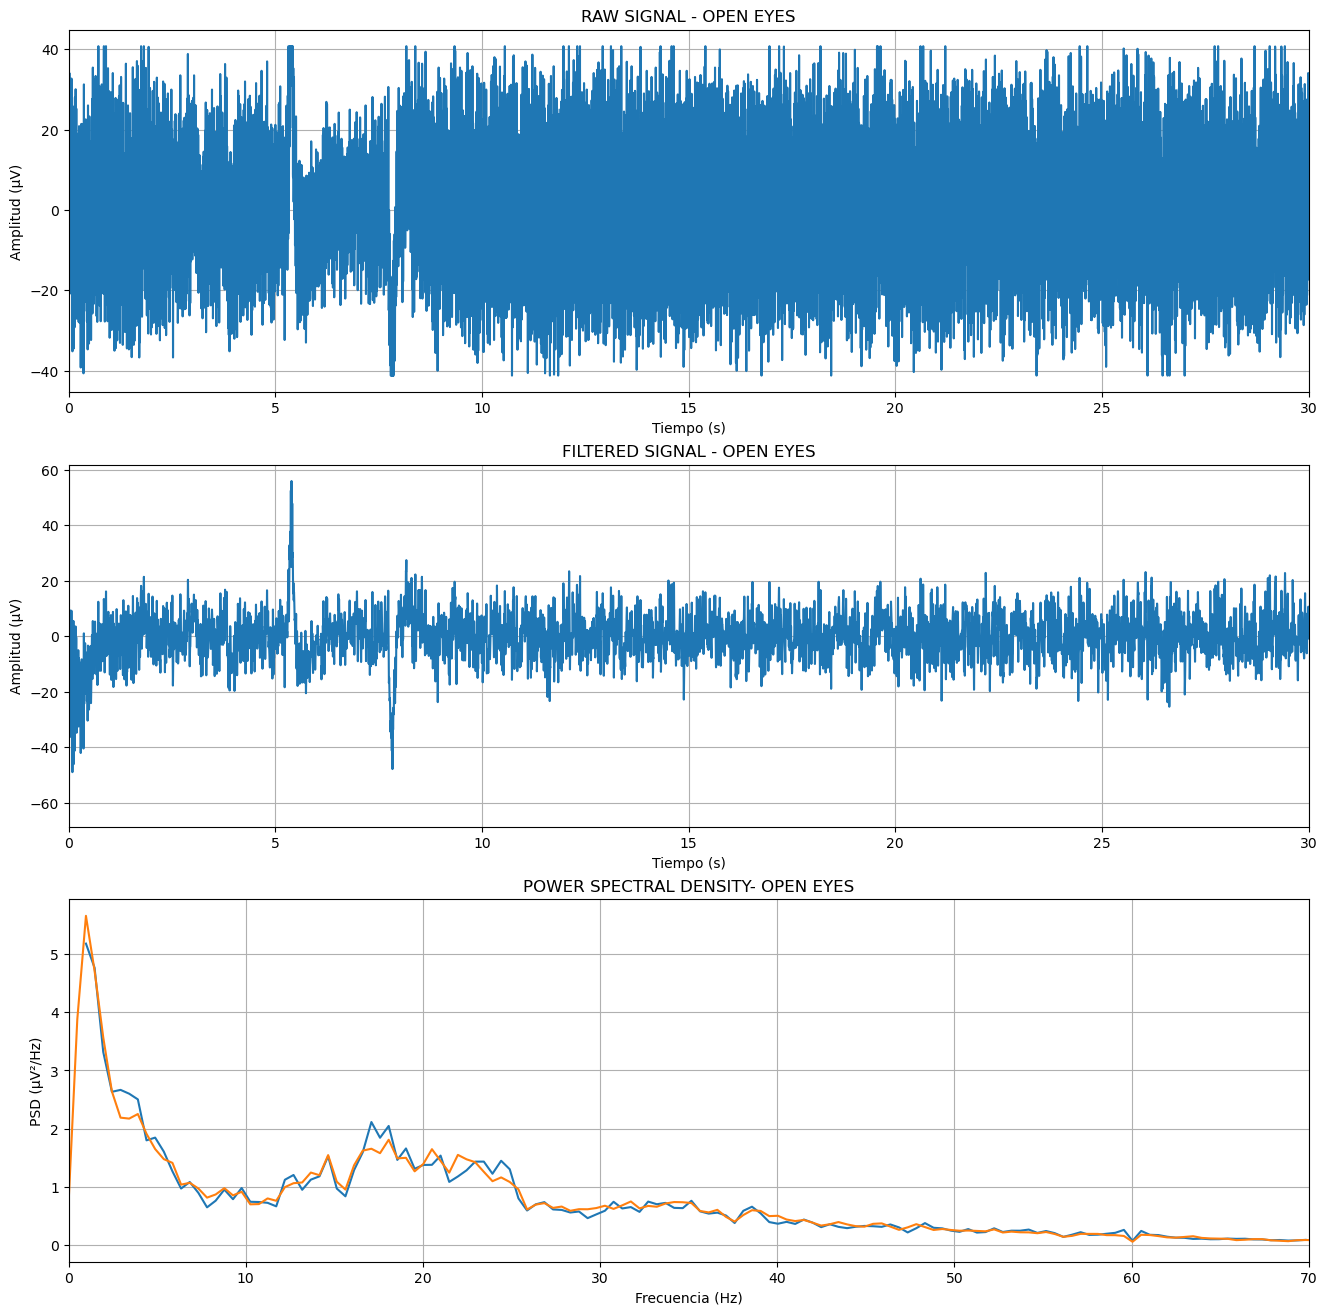

In [111]:
basal1, t1 = leer_eeg_bitalino("EEG Raw/puntofijo.txt")
basal1_filtered = filtrar_eeg(basal1)
psd1, f1 = obtain_psd(basal1_filtered)
fw1, psdw1 = welch(basal1_filtered, fs=1000, nperseg=2048)

plt.figure(figsize=(16, 16))

plt.subplot(3,1,1);plt.plot(t1, basal1)
plt.xlim(0, t1[30000]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("RAW SIGNAL - OPEN EYES")

plt.subplot(3,1,2);plt.plot(t1, basal1_filtered)
plt.xlim(0,t1[30000]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FILTERED SIGNAL - OPEN EYES")

plt.subplot(3,1,3);plt.plot(f1, psd1); plt.plot(fw1,psdw1);plt.xlim(0, 70)
plt.ylabel("PSD (µV²/Hz)");plt.xlabel("Frecuencia (Hz)");plt.grid(True);plt.title("POWER SPECTRAL DENSITY- OPEN EYES")

plt.show()

## Basal 2 - Ojos cerrados

## Tarea Cognitiva - Ejercicios de razonamiento

Potencia beta - Reposo: 20.67 µV²
Potencia beta - Cognitiva: 11.83 µV²
Diferencia absoluta: -8.84 µV²
Diferencia relativa: -42.8%


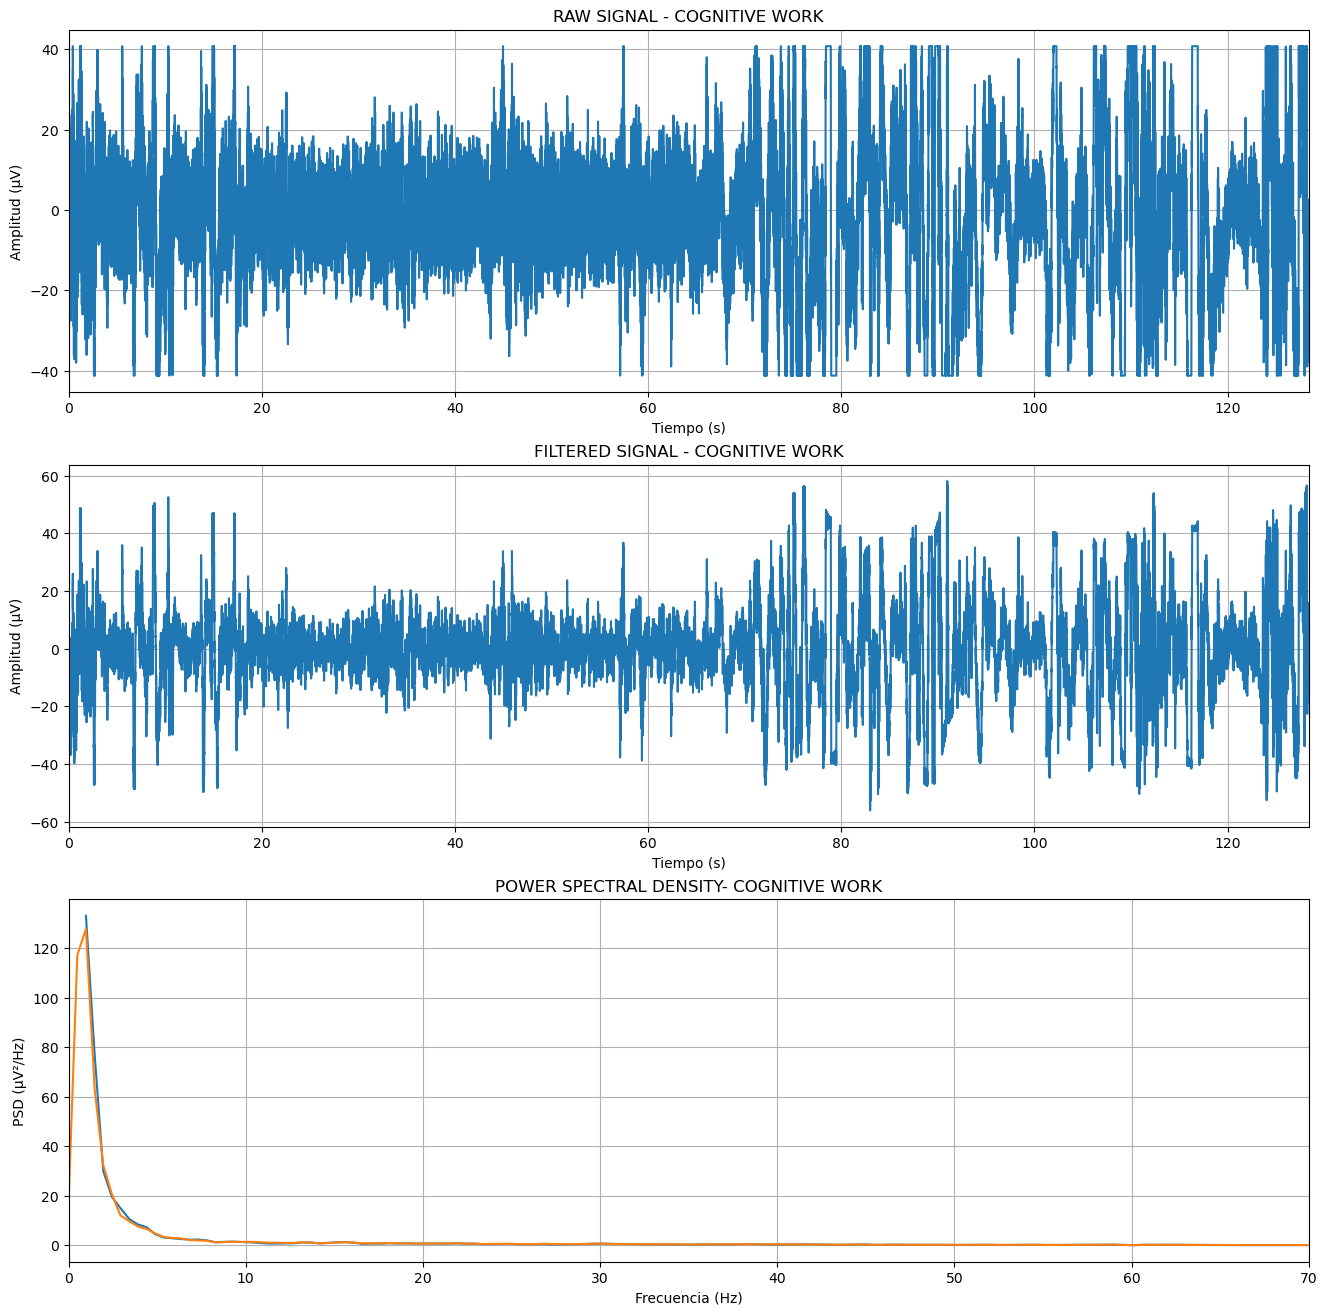

In [119]:
tarea_cognitiva, t2 = leer_eeg_bitalino("EEG Raw/cognitivos.txt")
tarea_cognitiva_filtered = filtrar_eeg(tarea_cognitiva)
psd2, f2 = obtain_psd(tarea_cognitiva_filtered)
fw2, psdw2 = welch(tarea_cognitiva_filtered, fs=1000, nperseg=2048)


plt.figure(figsize=(16, 16))

plt.subplot(3,1,1);plt.plot(t2, tarea_cognitiva)
plt.xlim(0, t2[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("RAW SIGNAL - COGNITIVE WORK")

plt.subplot(3,1,2);plt.plot(t2, tarea_cognitiva_filtered)
plt.xlim(0,t2[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FILTERED SIGNAL - COGNITIVE WORK")

plt.subplot(3,1,3);plt.plot(f2, psd2);plt.plot(fw2,psdw2);plt.xlim(0, 70)
plt.ylabel("PSD (µV²/Hz)");plt.xlabel("Frecuencia (Hz)");plt.grid(True);plt.title("POWER SPECTRAL DENSITY- COGNITIVE WORK")

plt.show()

## Artefacto 1 - Parpadeos continuos

Número de parpadeos detectados en la primera grabación: 21
Número de parpadeos detectados en la segunda grabación: 28


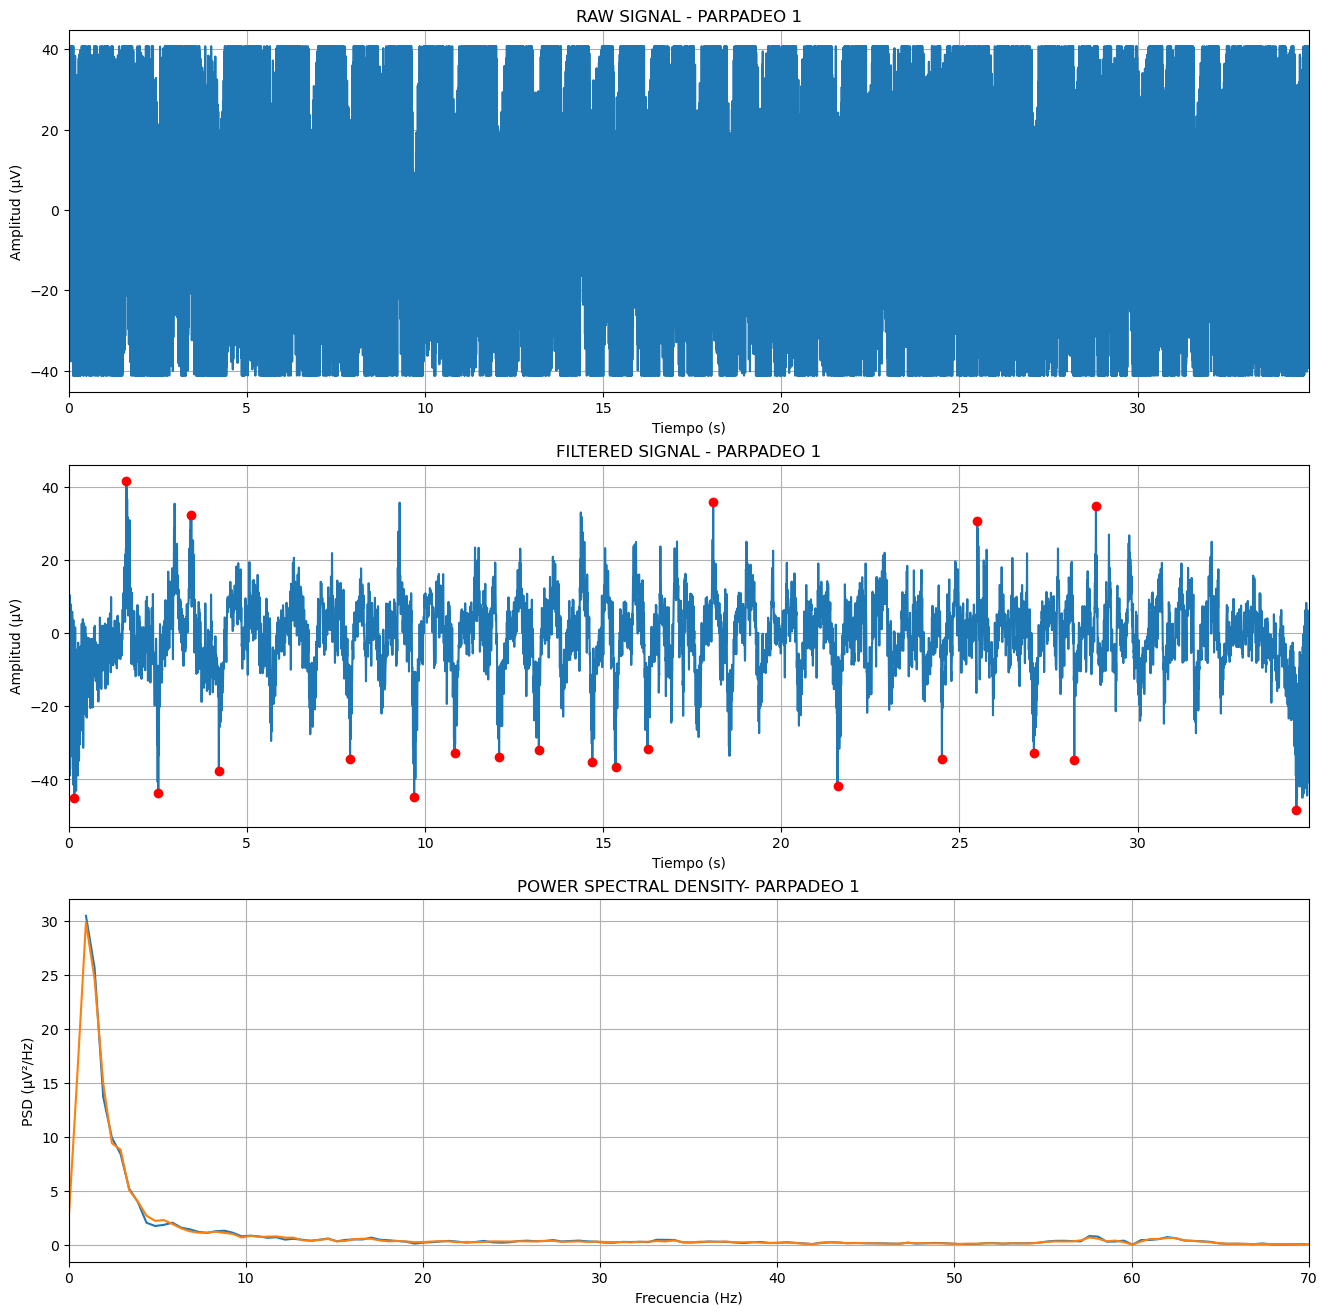

In [121]:
parpadeo1, t3 = leer_eeg_bitalino("EEG Raw/parpadeo1.txt")
parpadeo2, t4 = leer_eeg_bitalino("EEG Raw/parpadeo2.txt")
parpadeo1_filtered = filtrar_eeg(parpadeo1)
parpadeo2_filtered = filtrar_eeg(parpadeo2)
psd3, f3 = obtain_psd(parpadeo1_filtered)
psd4, f4 = obtain_psd(parpadeo2_filtered)
fw3, psdw3 = welch(parpadeo1_filtered, fs=1000, nperseg=2048)
fw4, psdw4 = welch(parpadeo2_filtered, fs=1000, nperseg=2048)

indices_1= detectar_parpadeos(parpadeo1_filtered, 30, 0.5)
indices_2= detectar_parpadeos(parpadeo2_filtered, 30, 0.5)
print(f"Número de parpadeos detectados en la primera grabación: {len(indices_1)}")
print(f"Número de parpadeos detectados en la segunda grabación: {len(indices_2)}")

plt.figure(figsize=(16, 16))

plt.subplot(3,1,1);plt.plot(t3, parpadeo1)
plt.xlim(0, t3[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("RAW SIGNAL - PARPADEO 1")

plt.subplot(3,1,2);plt.plot(t3, parpadeo1_filtered); plt.plot(t3[indices_1], parpadeo1_filtered[indices_1], 'ro')
plt.xlim(0,t3[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FILTERED SIGNAL - PARPADEO 1")

plt.subplot(3,1,3);plt.plot(f3, psd3);plt.plot(fw3,psdw3);plt.xlim(0, 70)
plt.ylabel("PSD (µV²/Hz)");plt.xlabel("Frecuencia (Hz)");plt.grid(True);plt.title("POWER SPECTRAL DENSITY- PARPADEO 1")

plt.show()

### En esta segunda grabación de parpadeos se le solicito a la participante, no parpadear durante los 10 primeros segundos de grabación, y efectivamente el algoritmo no esta contando mas que un parpadeo y dos falsos positivos

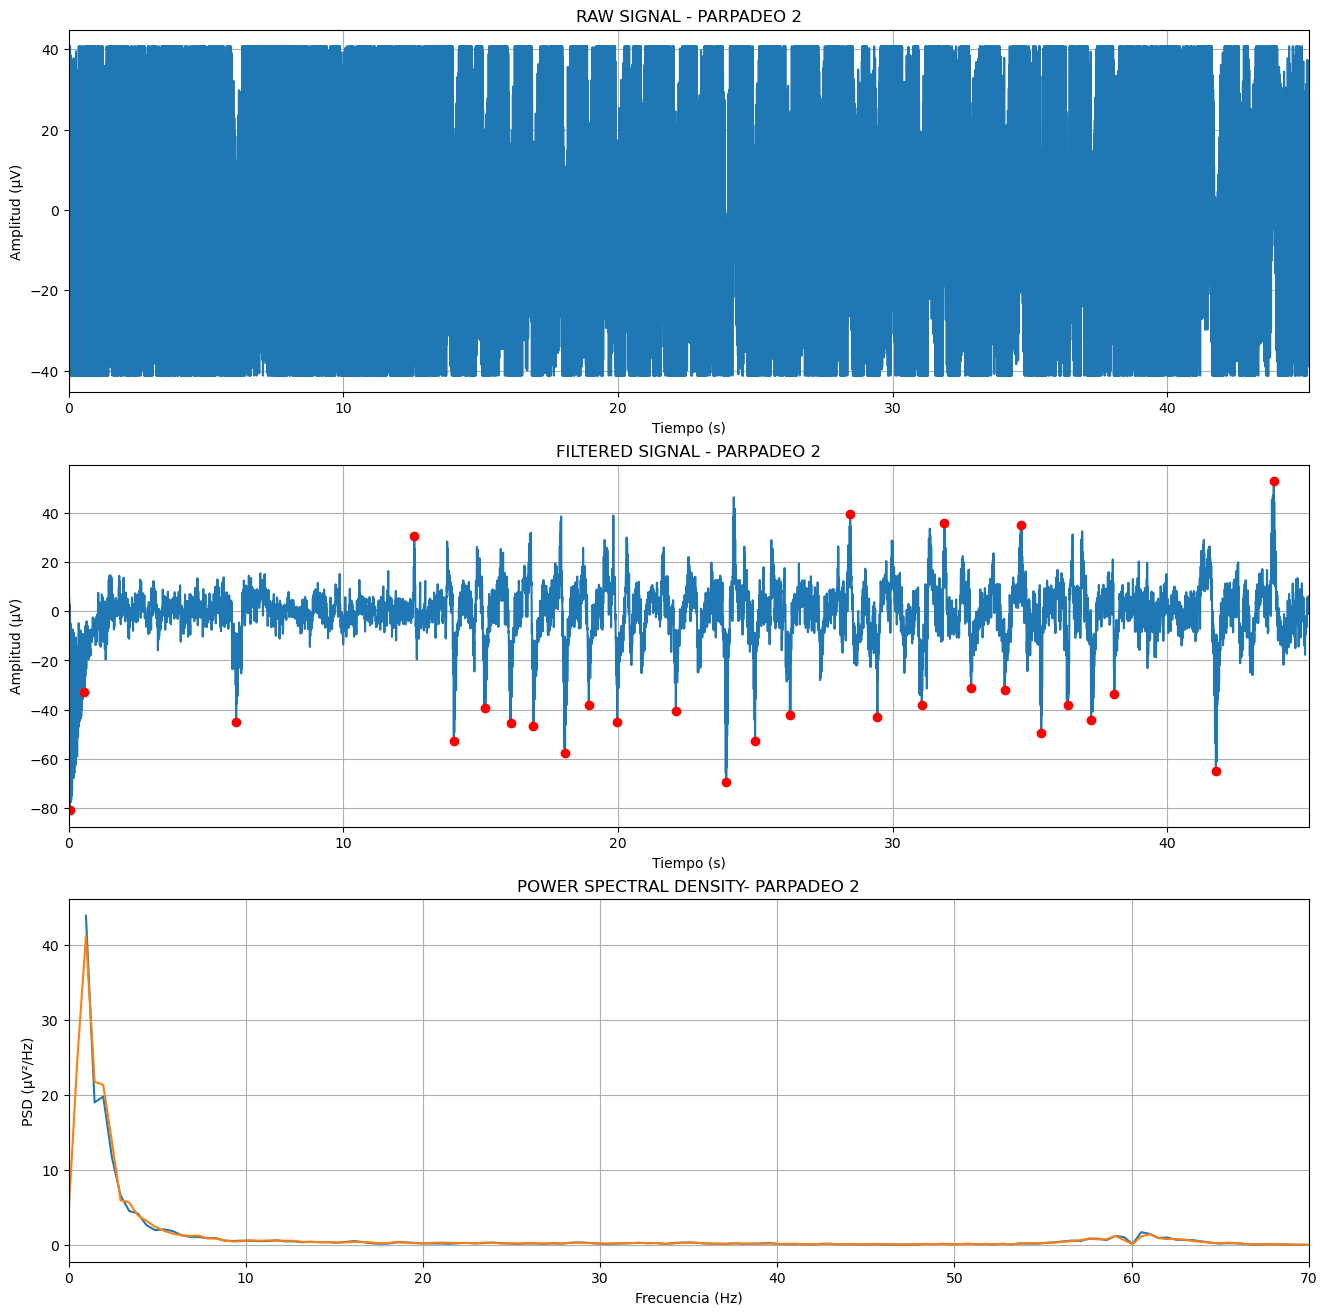

In [122]:
plt.figure(figsize=(16, 16))

plt.subplot(3,1,1);plt.plot(t4, parpadeo2)
plt.xlim(0, t4[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("RAW SIGNAL - PARPADEO 2")

plt.subplot(3,1,2);plt.plot(t4, parpadeo2_filtered); plt.plot(t4[indices_2], parpadeo2_filtered[indices_2], 'ro')
plt.xlim(0,t4[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FILTERED SIGNAL - PARPADEO 2")

plt.subplot(3,1,3);plt.plot(f4, psd4);plt.plot(fw4,psdw4);plt.xlim(0, 70)
plt.ylabel("PSD (µV²/Hz)");plt.xlabel("Frecuencia (Hz)");plt.grid(True);plt.title("POWER SPECTRAL DENSITY- PARPADEO 2")

plt.show()

## Artefacto 2 - Masticación

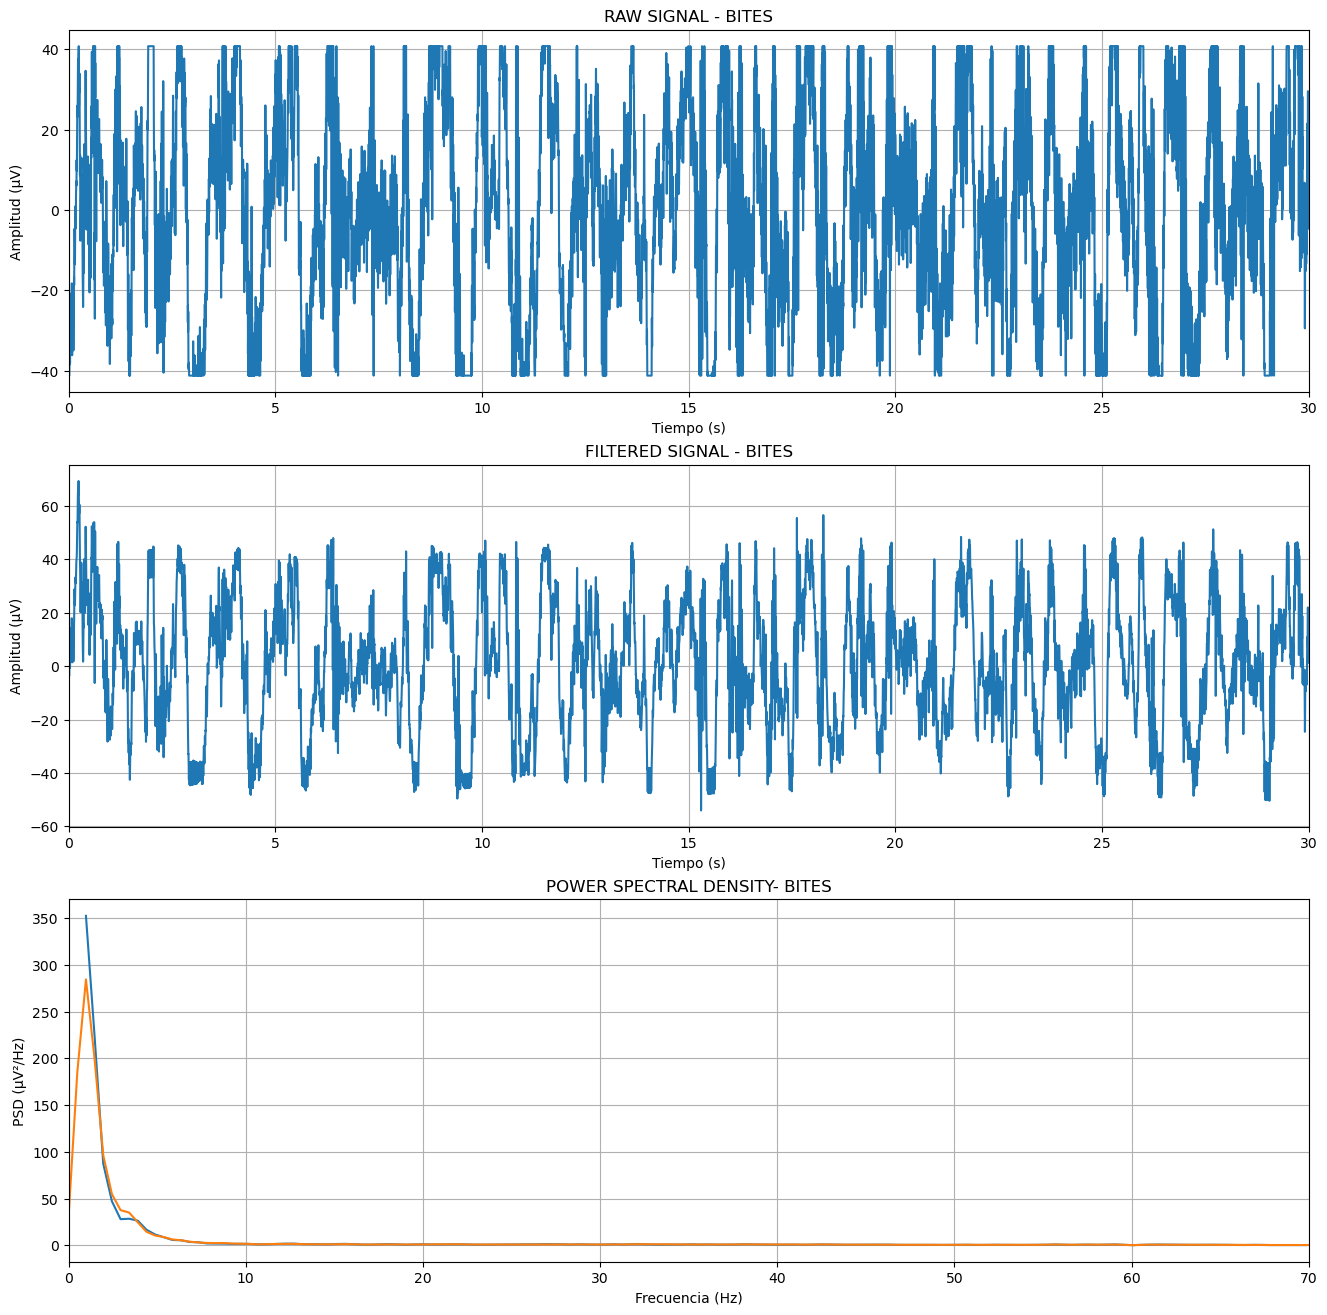

In [123]:
masticar, t5 = leer_eeg_bitalino("EEG Raw/masticar.txt")
masticar_filtered = filtrar_eeg(masticar)
psd5, f5 = obtain_psd(masticar_filtered)
fw5, psdw5 = welch(masticar_filtered, fs=1000, nperseg=2048)

plt.figure(figsize=(16, 16))

plt.subplot(3,1,1);plt.plot(t5, masticar)
plt.xlim(0, t5[30000]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("RAW SIGNAL - BITES")

plt.subplot(3,1,2);plt.plot(t5,masticar_filtered)
plt.xlim(0,t5[30000]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FILTERED SIGNAL - BITES")

plt.subplot(3,1,3);plt.plot(f5, psd5);plt.plot(fw5,psdw5);plt.xlim(0, 70)
plt.ylabel("PSD (µV²/Hz)");plt.xlabel("Frecuencia (Hz)");plt.grid(True);plt.title("POWER SPECTRAL DENSITY- BITES")

plt.show()

## Libre 1 - Música agradable

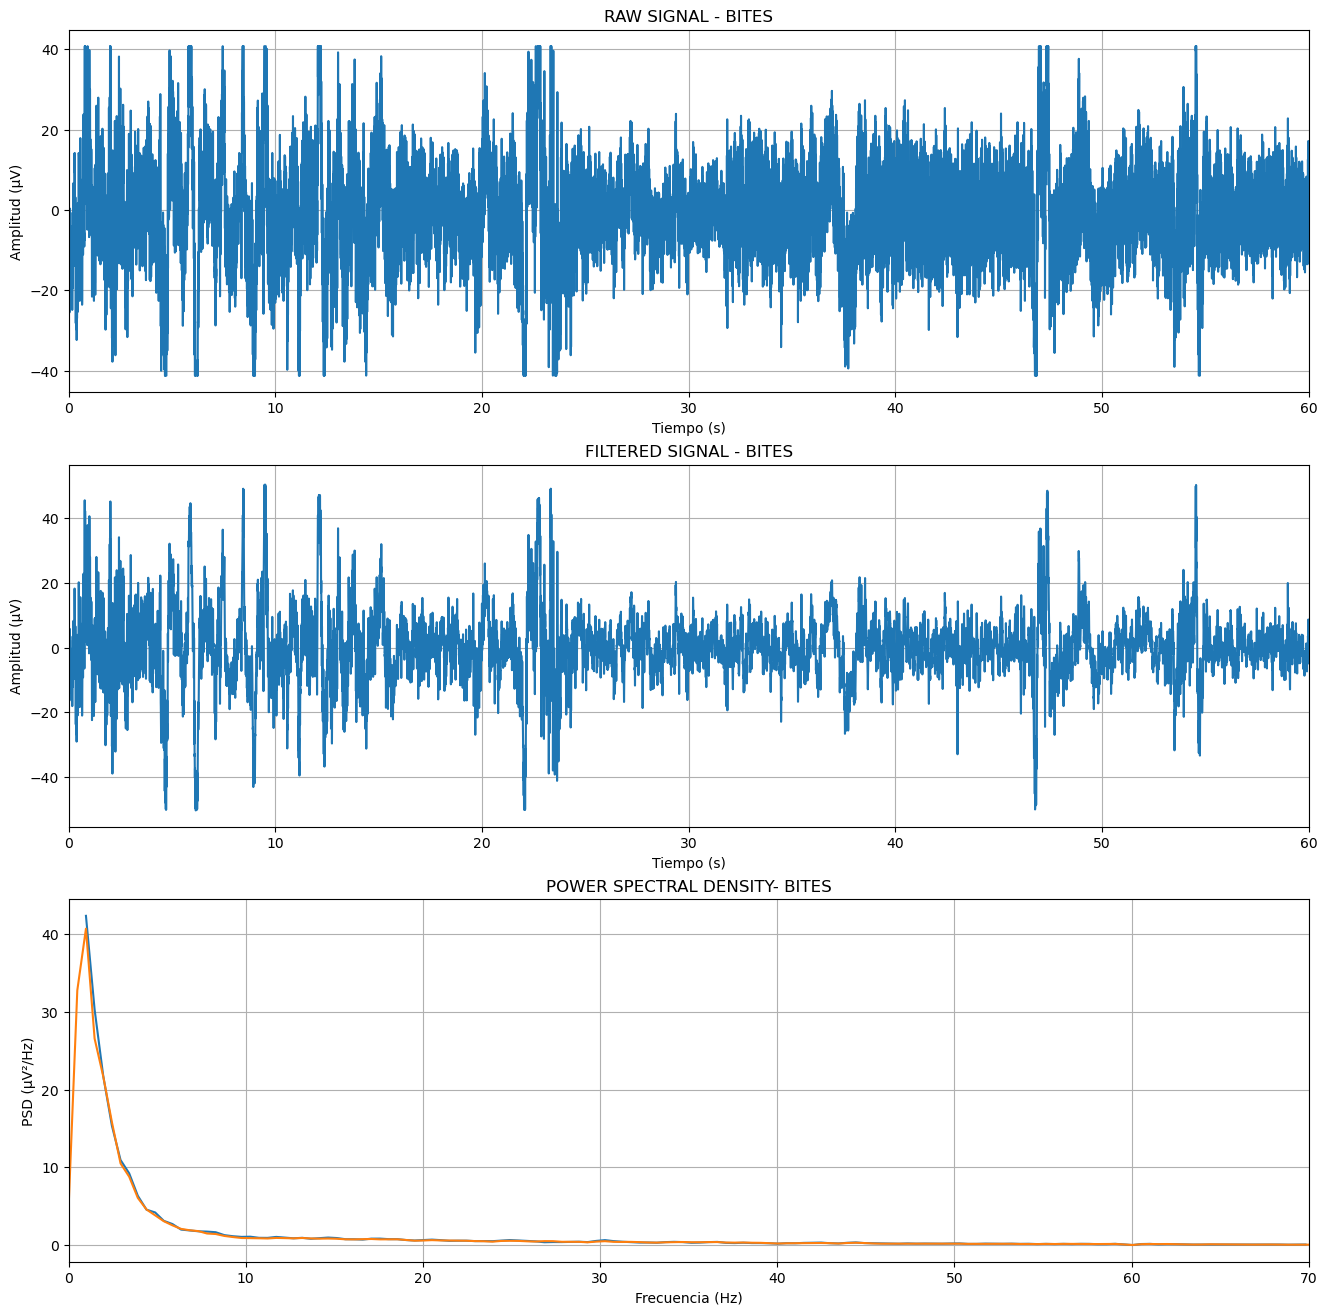

In [127]:
musica1, t6 = leer_eeg_bitalino("EEG Raw/musicaquelegusta.txt")
musica1_filtered = filtrar_eeg(musica1)
psd6, f6 = obtain_psd(musica1_filtered)
fw6, psdw6 = welch(musica1_filtered, fs=1000, nperseg=2048)

plt.figure(figsize=(16, 16))

plt.subplot(3,1,1);plt.plot(t6, musica1)
plt.xlim(0, t6[60000]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("RAW SIGNAL - BITES")

plt.subplot(3,1,2);plt.plot(t6, musica1_filtered)
plt.xlim(0,t6[60000]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FILTERED SIGNAL - BITES")

plt.subplot(3,1,3);plt.plot(f6, psd6);plt.plot(fw6,psdw6);plt.xlim(0, 70)
plt.ylabel("PSD (µV²/Hz)");plt.xlabel("Frecuencia (Hz)");plt.grid(True);plt.title("POWER SPECTRAL DENSITY- BITES")

plt.show()

## Libre 2 - Música desagradable

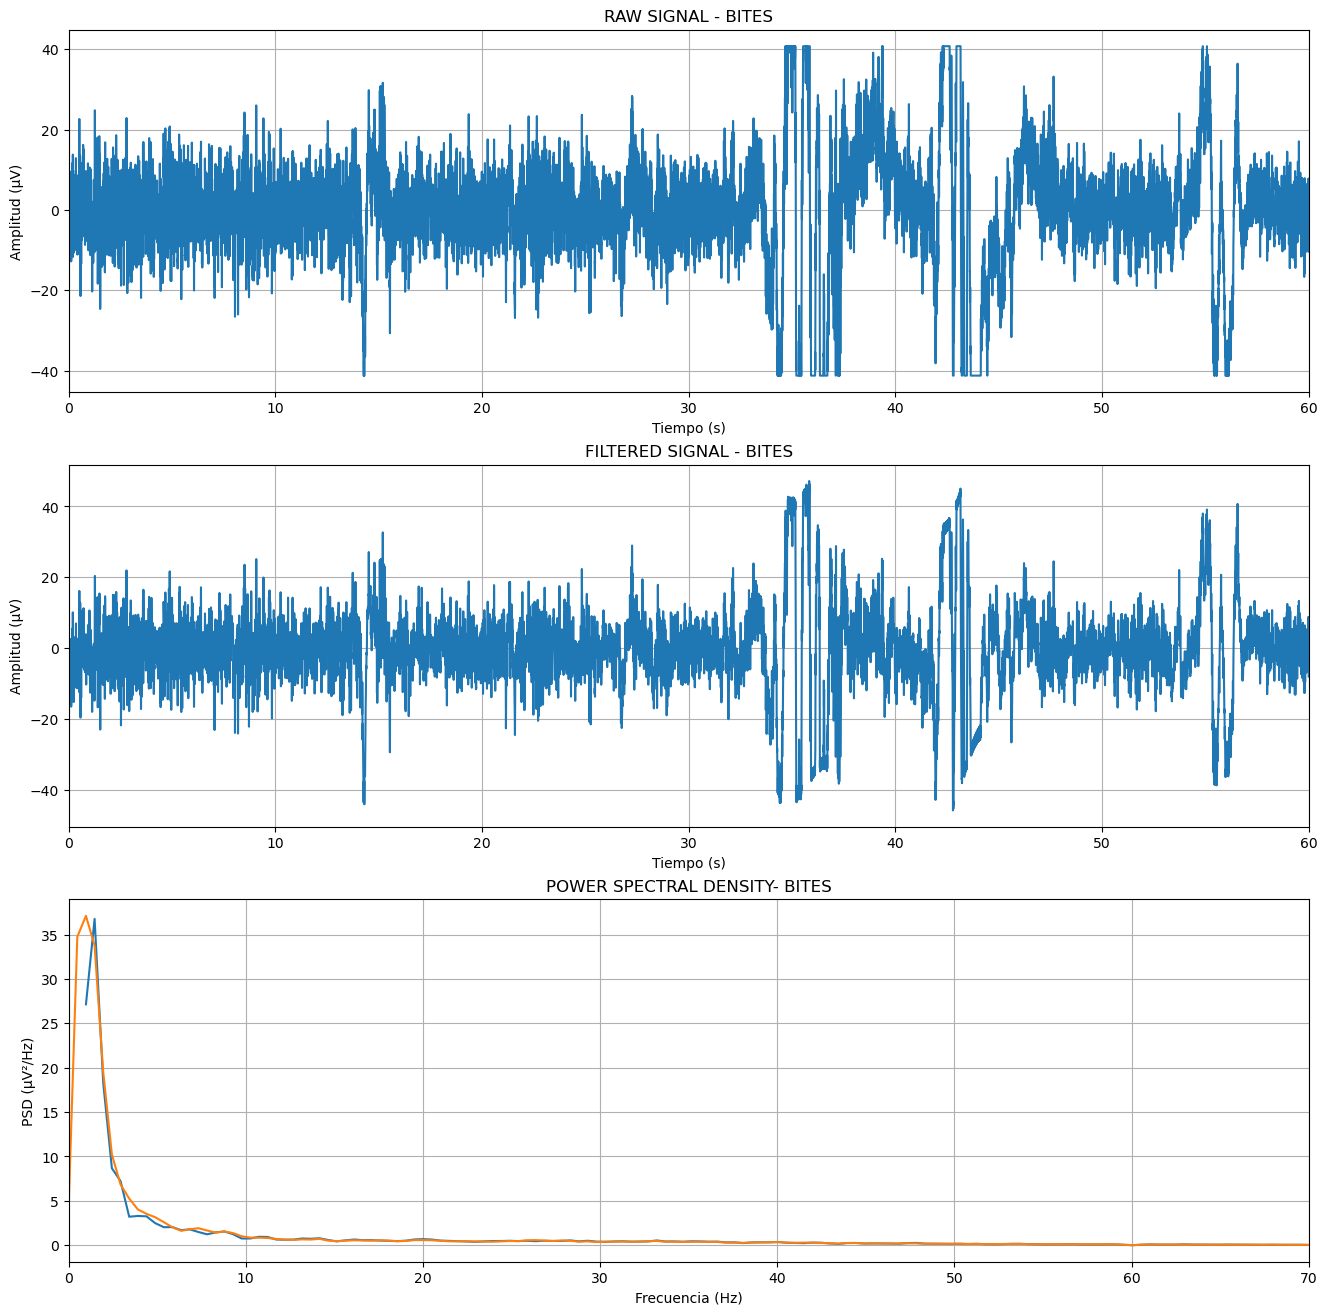

In [126]:
musica2, t7 = leer_eeg_bitalino("EEG Raw/musicaquenolegusta.txt")
musica2_filtered = filtrar_eeg(musica2)
psd7, f7 = obtain_psd(musica2_filtered)
fw7, psdw7 = welch(musica2_filtered, fs=1000, nperseg=2048)

plt.figure(figsize=(16, 16))

plt.subplot(3,1,1);plt.plot(t7, musica2)
plt.xlim(0, t7[60000]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("RAW SIGNAL - BITES")

plt.subplot(3,1,2);plt.plot(t7, musica2_filtered)
plt.xlim(0,t7[60000]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FILTERED SIGNAL - BITES")

plt.subplot(3,1,3);plt.plot(f7, psd7);plt.plot(fw7, psdw7);plt.xlim(0, 70)
plt.ylabel("PSD (µV²/Hz)");plt.xlabel("Frecuencia (Hz)");plt.grid(True);plt.title("POWER SPECTRAL DENSITY- BITES")

plt.show()

## Comparar PSD de Todas las grabaciones

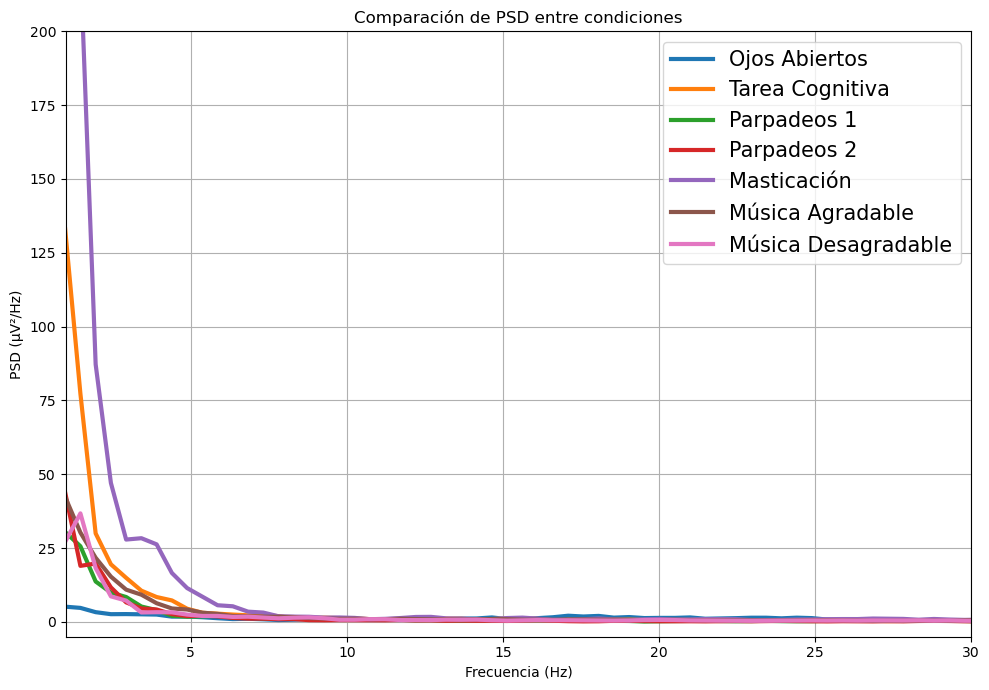

In [120]:
plt.figure(figsize=(10,7))
plt.plot(f1, psd1, label='Ojos Abiertos', linewidth=3)
plt.plot(f2, psd2, label='Tarea Cognitiva', linewidth=3)
plt.plot(f3, psd3, label='Parpadeos 1', linewidth=3)
plt.plot(f4, psd4, label='Parpadeos 2', linewidth=3)
plt.plot(f5, psd5, label='Masticación', linewidth=3)
plt.plot(f6, psd6, label='Música Agradable', linewidth=3)
plt.plot(f7, psd7, label='Música Desagradable', linewidth=3)
plt.legend(fontsize=15)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (µV²/Hz)")

plt.xlim(1, 30)
plt.ylim(-5, 200)
plt.title("Comparación de PSD entre condiciones")
plt.grid(True)
plt.tight_layout()
plt.show()